# IT25101303 — Kumarasingha I.S.N.P
## Preprocessing Technique: Categorical Encoding

**Assigned dataset:** Real-World Style Fitness Classification Dataset (Synthetic)  
**Target variable:** `is_fit`  
**Assigned technique:** Encode the categorical `gender` column (`M` / `F`) into a
numeric representation suitable for machine learning models.

### Why this technique is needed
Most machine learning algorithms (SVM, Neural Networks, Logistic Regression,
K-Means, etc.) require purely numeric input and cannot operate directly on text
labels such as `"M"` or `"F"`. `gender` is a **nominal** categorical variable
(no inherent order), so it must be encoded in a way that does not artificially
imply an ordering between the categories.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('../data/raw/fitness_dataset.csv')
df['gender'].value_counts()


gender
F    1030
M     970
Name: count, dtype: int64

### EDA Visualization — `gender` vs `is_fit` (BEFORE encoding)

A countplot of the raw categorical values lets us see class balance and whether
fitness status differs by gender, before any encoding is applied.

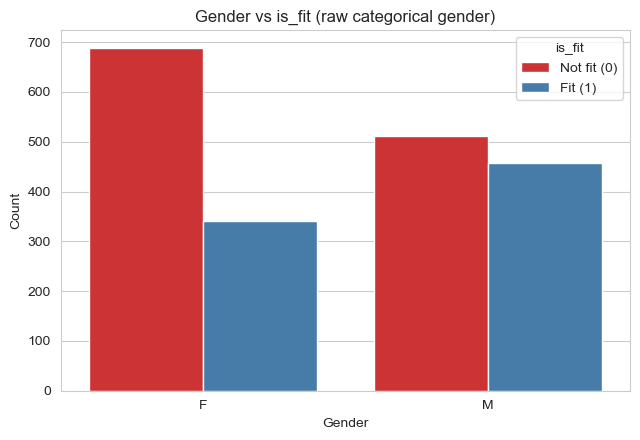

In [2]:
fig, ax = plt.subplots(figsize=(6.5,4.5))
sns.countplot(data=df, x='gender', hue='is_fit', palette='Set1', ax=ax)
ax.set_title('Gender vs is_fit (raw categorical gender)')
ax.set_xlabel('Gender')
ax.set_ylabel('Count')
ax.legend(title='is_fit', labels=['Not fit (0)', 'Fit (1)'])
plt.tight_layout()
plt.savefig('../results/eda_visualizations/member4_gender_vs_isfit_countplot.png', dpi=110, bbox_inches='tight')
plt.show()


**Interpretation:** The countplot shows the number of fit vs not-fit
individuals within each gender group. Both genders are reasonably represented, and
the fit/not-fit split looks broadly similar across `M` and `F`, suggesting `gender`
alone may be a weak predictor — but it is still worth including as a feature since
it may interact with other variables (e.g., activity level, nutrition).

In [3]:
# Step 1: One-Hot Encoding (recommended for nominal, unordered categories like gender)
df_encoded = df.copy()
df_encoded = pd.get_dummies(df_encoded, columns=['gender'], prefix='gender', drop_first=True)

# drop_first=True avoids the "dummy variable trap" (perfect multicollinearity)
# since with 2 categories, one binary column (e.g., gender_M) is sufficient.
print(df_encoded.filter(like='gender').head())
print()
print("New columns introduced:", [c for c in df_encoded.columns if c.startswith('gender')])


   gender_M
0     False
1     False
2     False
3      True
4     False

New columns introduced: ['gender_M']


### Alternative: Label Encoding (for comparison)

Label encoding is shown here for completeness/comparison, but **one-hot encoding
is the technique used going forward** in the group pipeline, since `gender` has no
natural order and label encoding (0/1) could mislead a model into assuming a
false ordinal relationship for algorithms that are sensitive to magnitude (e.g.,
distance-based models, though for a strictly binary category the practical risk is
low — this is included mainly to demonstrate the two common encoding approaches).

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
label_demo = df[['gender']].copy()
label_demo['gender_label_encoded'] = le.fit_transform(label_demo['gender'])
print("Label encoding mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
label_demo.drop_duplicates()


Label encoding mapping: {'F': np.int64(0), 'M': np.int64(1)}


### Justification recap
- **Technique:** One-hot encoding of `gender` (with `drop_first=True`) as the final
  chosen technique; label encoding shown as an alternative for comparison.
- **Why:** `gender` is nominal (no order); one-hot encoding avoids implying a false
  ranking between categories and is the standard approach for low-cardinality
  nominal features.
- **Output:** `df_encoded` — dataset with a numeric `gender_M` column
  (1 = Male, 0 = Female) replacing the original text `gender` column.

In [5]:
df_encoded.to_csv('../results/outputs/member4_gender_encoded.csv', index=False)
print("Saved encoded output to results/outputs/member4_gender_encoded.csv")


Saved encoded output to results/outputs/member4_gender_encoded.csv
